### Basic Summary and Target Distribution

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/vocal_gender_features_new.csv')


In [4]:
# Display shape and basic info
print("Dataset Shape:", df.shape)
print("\nData Types and Non-Null Counts:\n")
print(df.info())

Dataset Shape: (16148, 44)

Data Types and Non-Null Counts:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16148 entries, 0 to 16147
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean_spectral_centroid   16148 non-null  float64
 1   std_spectral_centroid    16148 non-null  float64
 2   mean_spectral_bandwidth  16148 non-null  float64
 3   std_spectral_bandwidth   16148 non-null  float64
 4   mean_spectral_contrast   16148 non-null  float64
 5   mean_spectral_flatness   16148 non-null  float64
 6   mean_spectral_rolloff    16148 non-null  float64
 7   zero_crossing_rate       16148 non-null  float64
 8   rms_energy               16148 non-null  float64
 9   mean_pitch               16148 non-null  float64
 10  min_pitch                16148 non-null  float64
 11  max_pitch                16148 non-null  float64
 12  std_pitch                16148 non-null  float64
 13  spectral_skew  

In [5]:
# Display basic statistics
print("\nSummary Statistics:\n")
print(df.describe())


Summary Statistics:

       mean_spectral_centroid  std_spectral_centroid  mean_spectral_bandwidth  \
count            16148.000000           16148.000000             16148.000000   
mean              1709.269730            1027.564673              1584.195931   
std                315.558063             286.303662               126.360465   
min                719.559285             194.998983              1106.939002   
25%               1475.078509             829.195585              1503.301521   
50%               1703.038854            1048.531356              1583.959951   
75%               1921.202685            1233.451527              1665.806788   
max               3059.390150            1912.173446              2046.070801   

       std_spectral_bandwidth  mean_spectral_contrast  mean_spectral_flatness  \
count            16148.000000            16148.000000            16148.000000   
mean               432.492328               20.395652                0.023086   
std  

In [6]:
# Check the distribution of the target variable (label: 0 = Female, 1 = Male)
print("\nLabel Distribution:\n")
print(df['label'].value_counts())


Label Distribution:

label
1    10380
0     5768
Name: count, dtype: int64


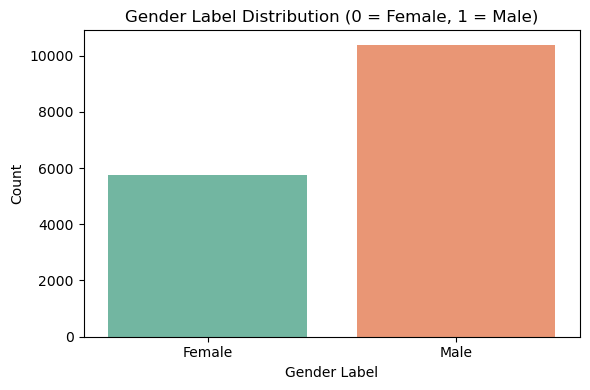

In [7]:
# Plot label distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', palette='Set2')
plt.title('Gender Label Distribution (0 = Female, 1 = Male)')
plt.xlabel('Gender Label')
plt.ylabel('Count')
plt.xticks([0, 1], ['Female', 'Male'])
plt.tight_layout()
plt.show()

### Data Cleaning and Correlation Heatmap


In [8]:
# Check for missing values
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

mean_spectral_centroid     0
std_spectral_centroid      0
mean_spectral_bandwidth    0
std_spectral_bandwidth     0
mean_spectral_contrast     0
mean_spectral_flatness     0
mean_spectral_rolloff      0
zero_crossing_rate         0
rms_energy                 0
mean_pitch                 0
min_pitch                  0
max_pitch                  0
std_pitch                  0
spectral_skew              0
spectral_kurtosis          0
energy_entropy             0
log_energy                 0
mfcc_1_mean                0
mfcc_1_std                 0
mfcc_2_mean                0
mfcc_2_std                 0
mfcc_3_mean                0
mfcc_3_std                 0
mfcc_4_mean                0
mfcc_4_std                 0
mfcc_5_mean                0
mfcc_5_std                 0
mfcc_6_mean                0
mfcc_6_std                 0
mfcc_7_mean                0
mfcc_7_std                 0
mfcc_8_mean                0
mfcc_8_std                 0
mfcc_9_mean               

In [9]:
# Check for duplicates
num_duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {num_duplicates}")


Number of duplicate rows: 1078


In [10]:
# Remove duplicates if any
if num_duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found.")

Duplicates removed. New shape: (15070, 44)


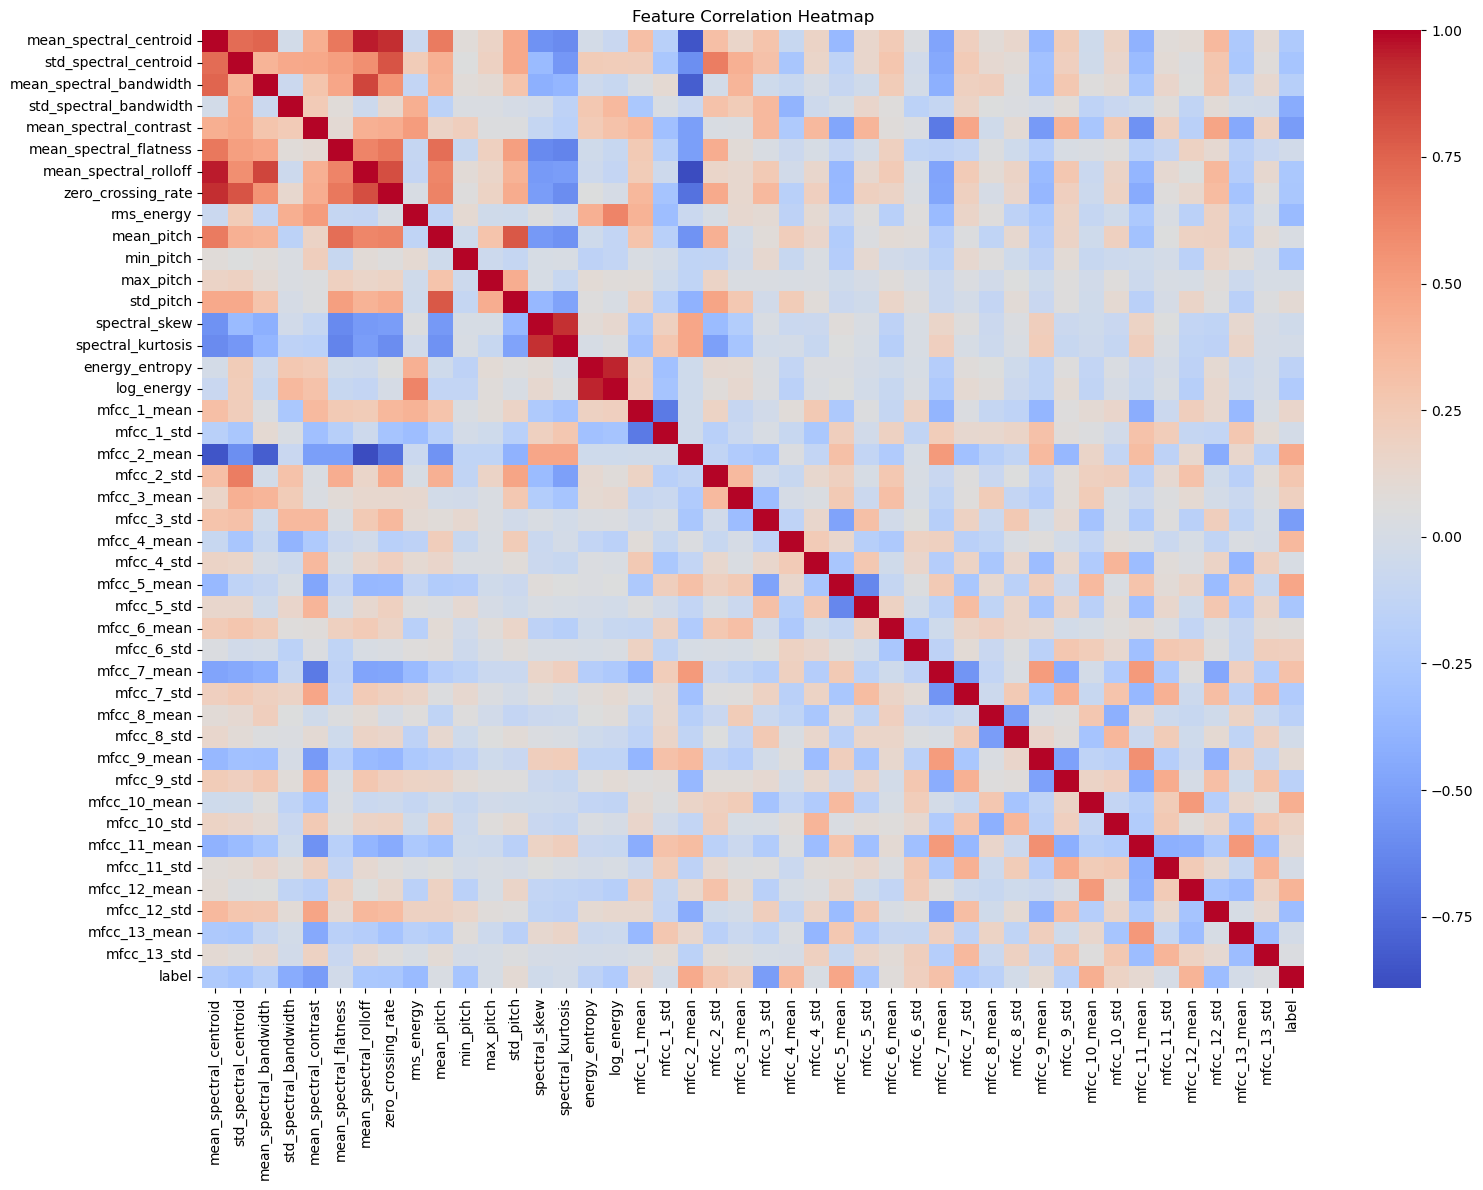

In [11]:
# 3. Correlation Heatmap (numeric features only)
plt.figure(figsize=(16, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### Feature Distribution Visualization

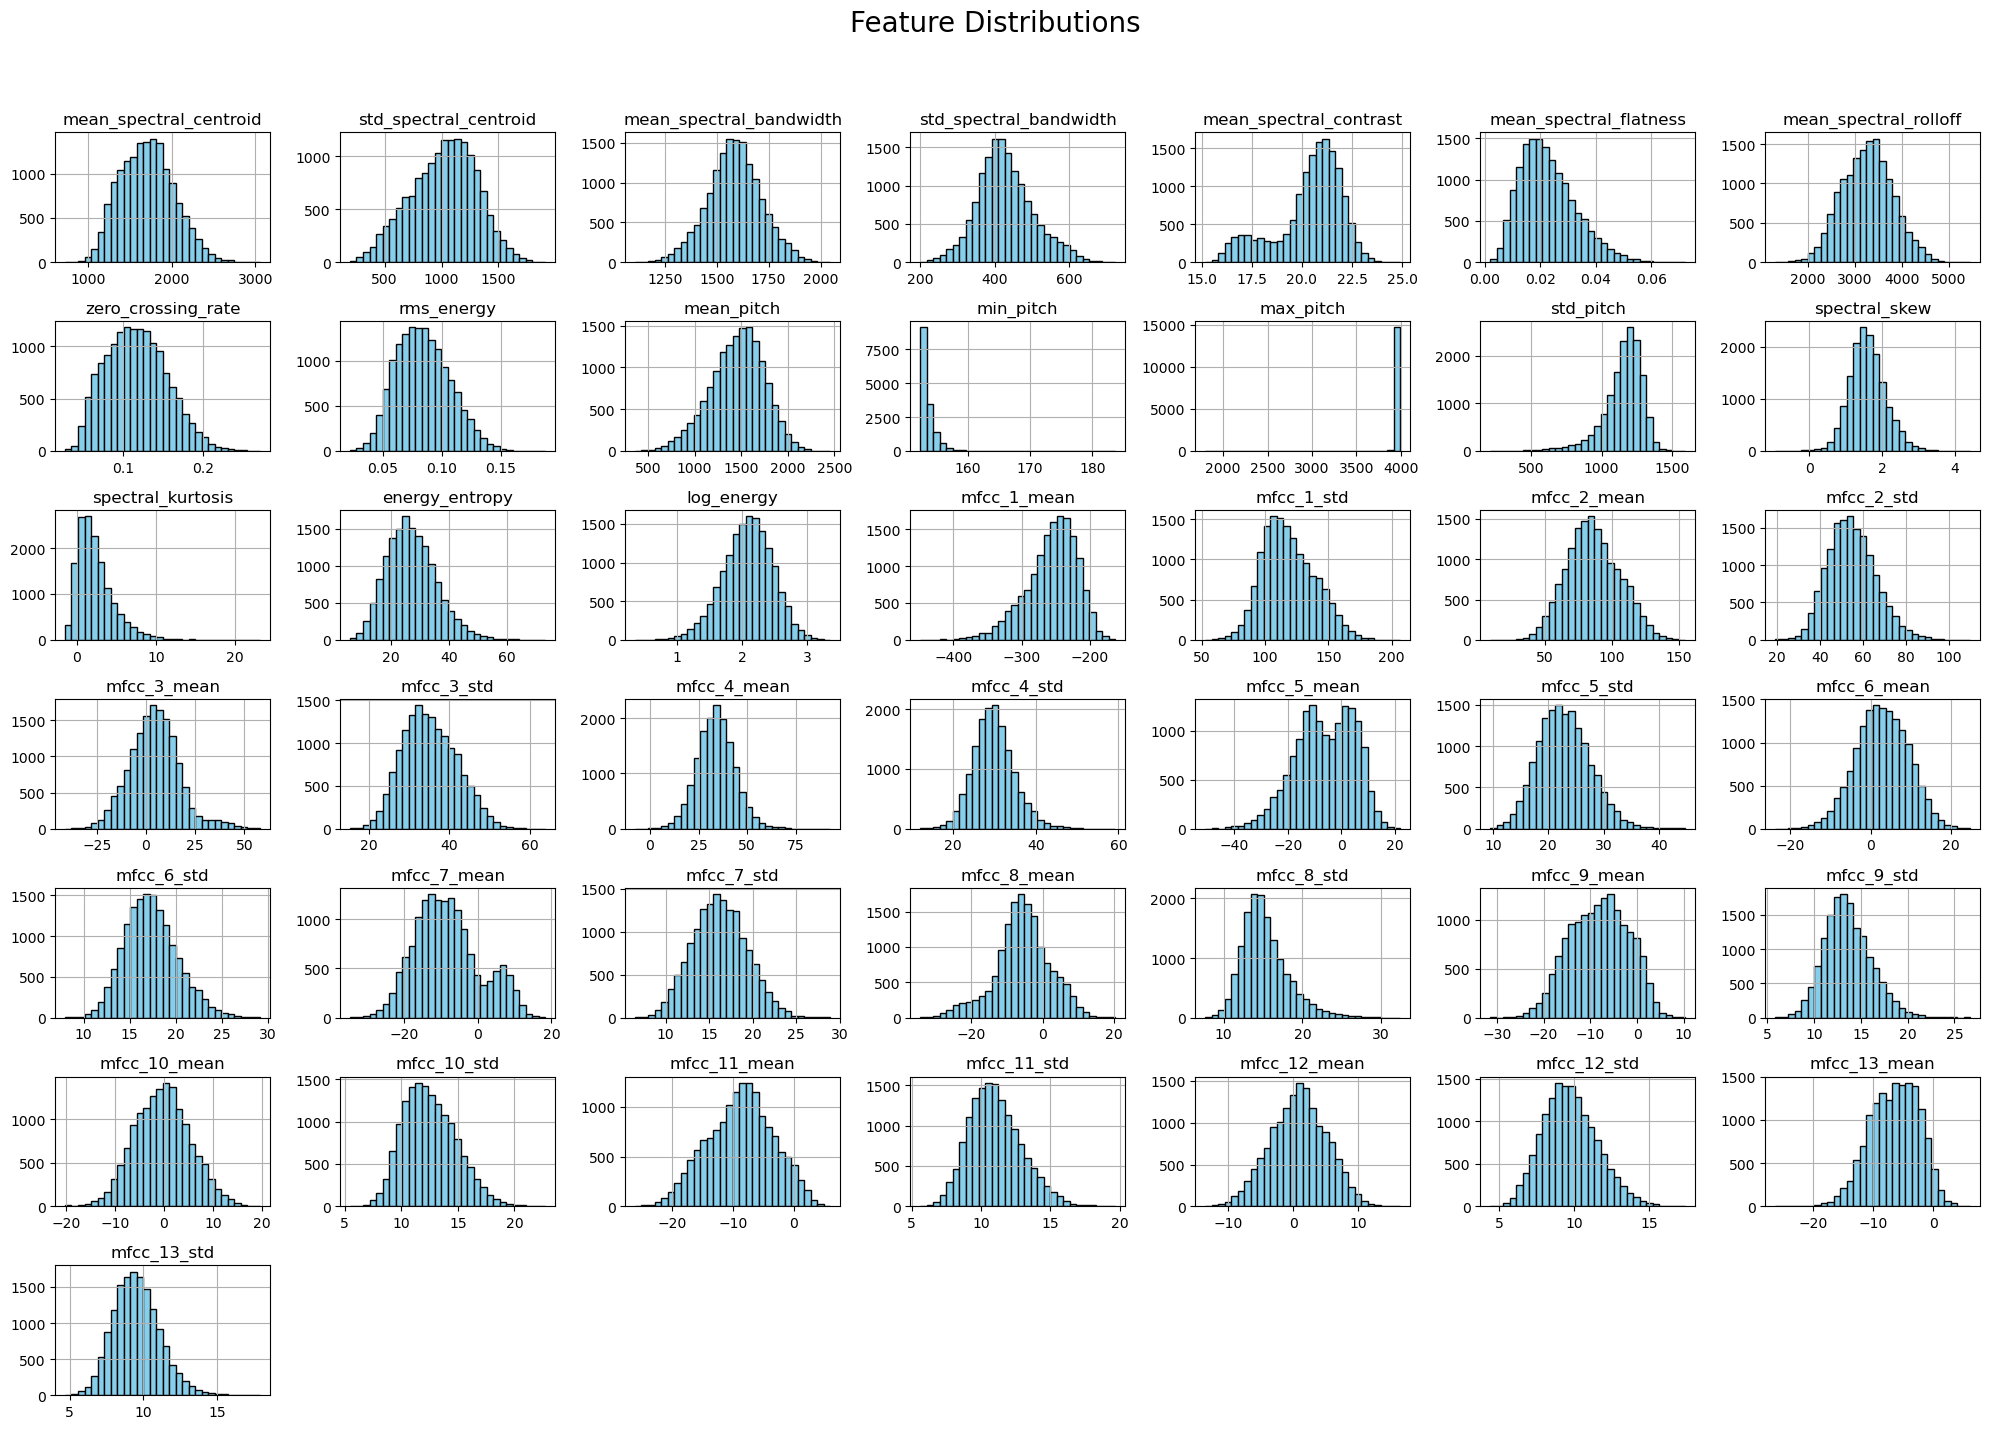

In [ ]:
# Histogram of all features
df.drop('label', axis=1).hist(figsize=(20, 15), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

C:\Users\shubh\AppData\Local\Temp\ipykernel_10744\3467902454.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['label'] == 0][feature], label='Female (0)', shade=True)
C:\Users\shubh\AppData\Local\Temp\ipykernel_10744\3467902454.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['label'] == 1][feature], label='Male (1)', shade=True)


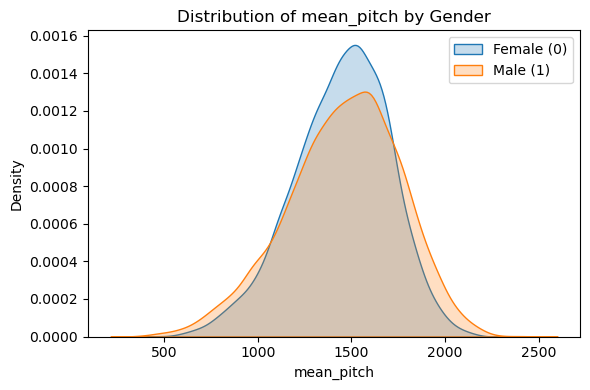

C:\Users\shubh\AppData\Local\Temp\ipykernel_10744\3467902454.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['label'] == 0][feature], label='Female (0)', shade=True)
C:\Users\shubh\AppData\Local\Temp\ipykernel_10744\3467902454.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['label'] == 1][feature], label='Male (1)', shade=True)


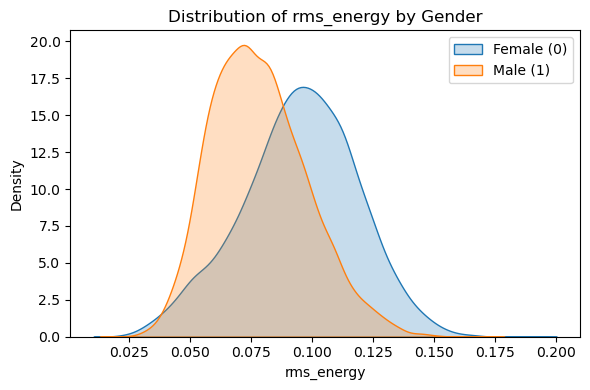

C:\Users\shubh\AppData\Local\Temp\ipykernel_10744\3467902454.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['label'] == 0][feature], label='Female (0)', shade=True)
C:\Users\shubh\AppData\Local\Temp\ipykernel_10744\3467902454.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['label'] == 1][feature], label='Male (1)', shade=True)


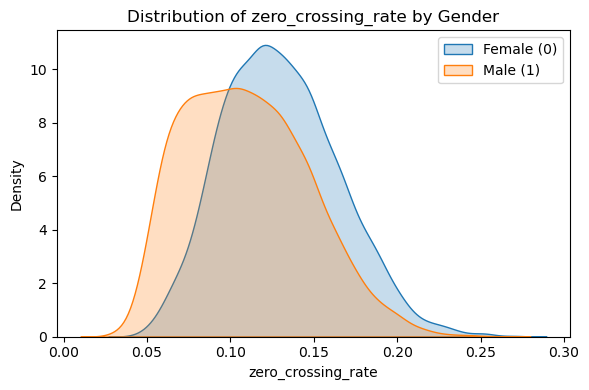

C:\Users\shubh\AppData\Local\Temp\ipykernel_10744\3467902454.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['label'] == 0][feature], label='Female (0)', shade=True)
C:\Users\shubh\AppData\Local\Temp\ipykernel_10744\3467902454.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['label'] == 1][feature], label='Male (1)', shade=True)


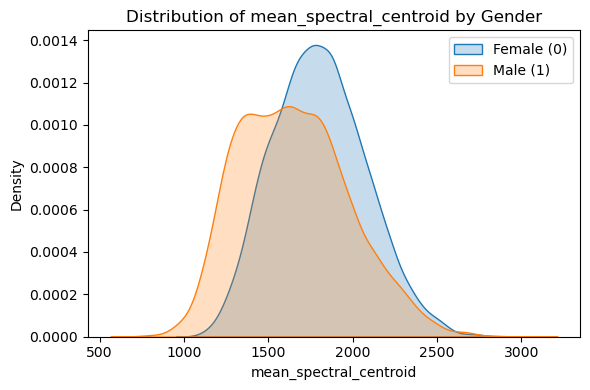

In [13]:
# KDE plots for selected features
selected_features = ['mean_pitch', 'rms_energy', 'zero_crossing_rate', 'mean_spectral_centroid']

for feature in selected_features:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(df[df['label'] == 0][feature], label='Female (0)', shade=True)
    sns.kdeplot(df[df['label'] == 1][feature], label='Male (1)', shade=True)
    plt.title(f'Distribution of {feature} by Gender')
    plt.xlabel(feature)
    plt.legend()
    plt.tight_layout()
    plt.show()

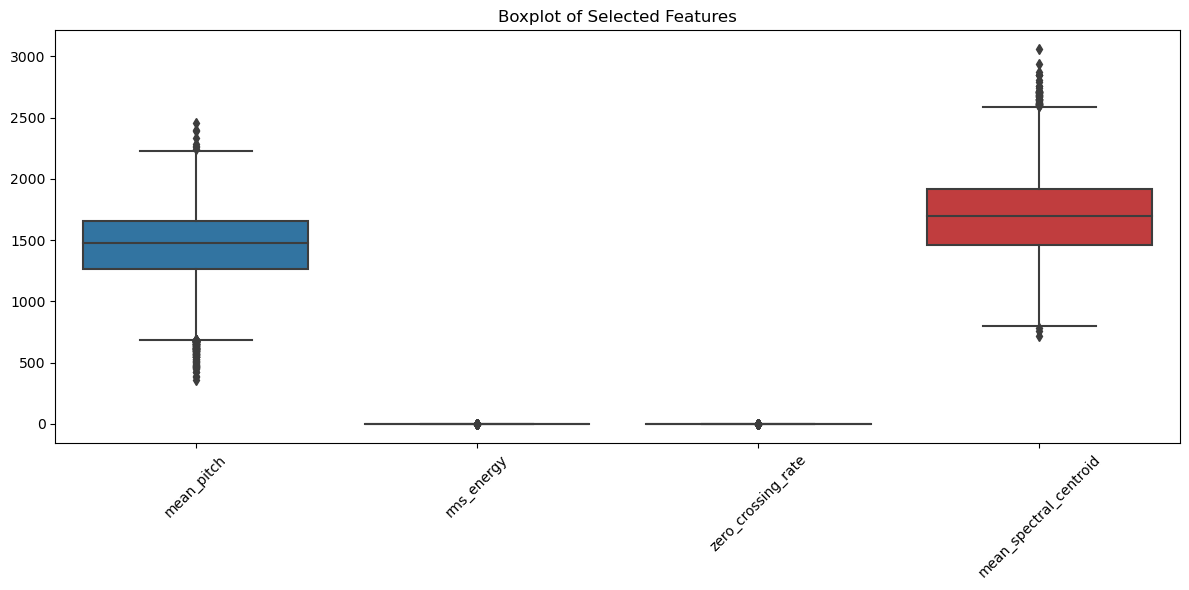

In [14]:
# Optional: Boxplots for outlier detection
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[selected_features])
plt.title("Boxplot of Selected Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [16]:
# 1. Split features and target
X = df.drop('label', axis=1)
y = df['label']

In [17]:
# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (10549, 43), Test shape: (4521, 43)


In [18]:
# 3. Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
# Optionally convert back to DataFrame for easy viewing
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

In [20]:
# Confirm scaling
X_train_scaled_df.describe().T[['mean', 'std']].head()

,mean,std
mean_spectral_centroid,-4.997845e-16,1.000047
std_spectral_centroid,3.394763e-16,1.000047
mean_spectral_bandwidth,1.130241e-15,1.000047
std_spectral_bandwidth,-3.017567e-16,1.000047
mean_spectral_contrast,3.839315e-16,1.000047


In [21]:
# Remove duplicates (if not already done)
df = df.drop_duplicates()

# Save to CSV
df.to_csv(r'D:\Guvi\Projects\mini\Human Voice Classification and Clustering\Human_Voice_Classification_and_Clustering\data/vocal_gender_features_cleaned.csv', index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
